<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/05_pytorch_going_modular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bandgap Preidction of Inorganic Material with Two-Stage Neural Network**

Replication paper using PyTorch, Matminer, and composition descriptor.

* Rio Agustian Gilang Fernandp
* Advanced Material Science and Nanotechnology

This notebook is based on this paper: https://doi.org/10.1021/acs.jpclett.8b00124

1. Problem
  Experimental dataset has a lot of zero value (metal) that make the regular regression model can be bias and inaccurate.
2. Solution
  Make architecture two-stage piple using PyTorch. The first stage is detect metal or non metal (classifier). The second stage is predict the bandgap energy (regression) only for non metal.
3. Feature engineering
  Change from molecule string to numerical vector with physical meaning using compositional descriptors (`Magpie` and `Matminer`).
4. Tech Stack
  * `Python`, `PyTorch`, `Scikit-learn`, `Matminer`, `Pandas`.


# **1. Setup and Data Loading**

Prepare for the environment and load the raw data.

## 1.1 Import libraries

In [1]:
!pip install matminer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 806.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 7.3 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.3-py3-none-any.whl size=43549

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from matminer.datasets import load_dataset
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error

## 1.2 Load dataset

In [3]:
# Load dataset again to ensure a fresh start if the DataFrame was reset
from matminer.datasets import load_dataset
df = load_dataset('matbench_expt_gap')

Fetching matbench_expt_gap.json.gz from https://ml.materialsproject.org/projects/matbench_expt_gap.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_expt_gap.json.gz


Fetching https://ml.materialsproject.org/projects/matbench_expt_gap.json.gz in MB: 0.038911999999999995MB [00:00, 16.96MB/s]   


# **2. Feature Engineering**

Convert the molecule text to numbers

## 2.1 Convert string in column 'composition' to a Pymatgen object composition

In [4]:
from matminer.featurizers.conversions import StrToComposition

# convert string to object composition and store it in a new column
df = StrToComposition(target_col_id='composition_object').featurize_dataframe(df, "composition")

StrToComposition:   0%|          | 0/4604 [00:00<?, ?it/s]

In [5]:
df.head()

,composition,gap expt,composition_object
0,Ag(AuS)2,0.00,"(Ag, Au, S)"
1,Ag(W3Br7)2,0.00,"(Ag, W, Br)"
2,Ag0.5Ge1Pb1.75S4,1.83,"(Ag, Ge, Pb, S)"
3,Ag0.5Ge1Pb1.75Se4,1.51,"(Ag, Ge, Pb, Se)"
4,Ag2BBr,0.00,"(Ag, B, Br)"


## 2.2 Use Magpie Descriptors (use `ElementProperty` from `Matminer`) to have the statistics of the element (mass, electronegativity, radius, etc)

In [6]:
from matminer.featurizers.composition import ElementProperty

# generate features
ep_feat = ElementProperty.from_preset(preset_name="magpie", impute_nan=True)
df = ep_feat.featurize_dataframe(df, col_id="composition_object")
df.head()

ElementProperty:   0%|          | 0/4604 [00:00<?, ?it/s]

,composition,gap expt,composition_object,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Ag(AuS)2,0.00,"(Ag, Au, S)",16.0,79.0,63.0,47.400000,25.280000,16.0,65.0,...,0.0,0.0,0.0,0.0,70.0,225.0,155.0,163.000000,74.400000,70.0
1,Ag(W3Br7)2,0.00,"(Ag, W, Br)",35.0,74.0,39.0,46.714286,15.619048,35.0,51.0,...,0.0,0.0,0.0,0.0,64.0,229.0,165.0,118.809524,73.079365,64.0
2,Ag0.5Ge1Pb1.75S4,1.83,"(Ag, Ge, Pb, S)",16.0,82.0,66.0,36.275862,23.552913,16.0,65.0,...,0.0,0.0,0.0,0.0,70.0,225.0,155.0,139.482759,76.670630,70.0
3,Ag0.5Ge1Pb1.75Se4,1.51,"(Ag, Ge, Pb, Se)",32.0,82.0,50.0,46.206897,17.388823,34.0,65.0,...,0.0,0.0,0.0,0.0,14.0,225.0,211.0,108.586207,104.370987,14.0
4,Ag2BBr,0.00,"(Ag, B, Br)",5.0,47.0,42.0,33.500000,14.250000,47.0,65.0,...,0.0,0.0,0.0,0.0,64.0,225.0,161.0,170.000000,55.000000,225.0


## 2.3 Clean the data (drop the non numerical data column)

In [7]:
# delete non feature colomn (:composition and gap expt)
features_columns = [col for col in df.columns if col not in ["composition", "gap expt", "composition_object"]]
X = df[features_columns].values
y = df["gap expt"].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (4604, 132)
y shape: (4604,)


### **Python Script**


In [8]:
# create directory for goinG modular
import os
os.makedirs("going_modular")

In [9]:
%%writefile going_modular/data_setup.py
"""
Data loading and feature engineering.
Return (X, y)
"""
import os
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition
from matminer.datasets import load_dataset

NUM_WORKERS = os.cpu_count()
def create_dataloaders():
  # Load dataset again to ensure a fresh start if the DataFrame was reset
  print("Dataset loading...")
  df = load_dataset('matbench_expt_gap')

  # convert string to object composition and store it in a new column
  print("\nConvert string to compositions...")
  df = StrToComposition(target_col_id='composition_object').featurize_dataframe(df, "composition")

  # generate features
  print("Generating features...")
  ep_feat = ElementProperty.from_preset(preset_name="magpie", impute_nan=True)
  df = ep_feat.featurize_dataframe(df, col_id="composition_object")

  # delete non feature colomn (:composition and gap expt)
  print("Drop useless column...")
  features_columns = [col for col in df.columns if col not in ["composition", "gap expt", "composition_object"]]
  X = df[features_columns].values
  y = df["gap expt"].values
  print("---Finished!---")
  return X, y

Writing going_modular/data_setup.py


In [10]:
from going_modular import data_setup

X1, y1 = data_setup.create_dataloaders()

Dataset loading...

Convert string to compositions...


StrToComposition:   0%|          | 0/4604 [00:00<?, ?it/s]

Generating features...


ElementProperty:   0%|          | 0/4604 [00:00<?, ?it/s]

Drop useless column...
---Finished!---


# **3. Preprocessing and Data Splitting**

Prepare the data to be ready for Neural Network input.

## 3.1 Train-test Split (80 % training and 20 % testing)

In [11]:
# preprocessing
from sklearn.model_selection import train_test_split

# train test split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=67)

## 3.2 Scaling


In [12]:
from sklearn.preprocessing import StandardScaler

# normalize (important for convergence PyTorch Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

## 3.2 Convert to Tensor

In [42]:
import torch

# convert to PyTorch Tensor
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_raw, dtype=torch.float32).view(-1, 1)
X_test  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test  = torch.tensor(y_test_raw, dtype=torch.float32).view(-1, 1)

# **4. Model Architecture**

Design the neural network

In [14]:
import torch.nn as nn

# neural network (MLP)
class MLP(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.Linear(64, 32),
        nn.Linear(32, 1),
        nn.ReLU()
    )
  def forward(self, x):
    return self.layer_stack(x)

### **Python Script**

In [56]:
%%writefile going_modular/model_builder.py
"""
This contain simple MLP model.
"""
import torch.nn as nn
import torch

# neural network (MLP)
class MLP(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.Linear(64, 32),
        nn.Linear(32, 1),
        nn.ReLU()
    )
  def forward(self, x):
    return self.layer_stack(x)

Overwriting going_modular/model_builder.py


In [38]:
from going_modular import model_builder

input_dim = X_train.shape[1]
model_test = model_builder.MLP(input_dim)
model_test

MLP(
  (layer_stack): Sequential(
    (0): Linear(in_features=132, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): ReLU()
  )
)

# **5. Stage 1 Training: Classification**

## 5.1 Labelling

Make a binary label

```
if bandgap < 0.001:
  is_metal, label is 0
else:
  non_metal, label is 1
```

In [17]:
# make label, 1 if non-metal and 0 if metal
y_train_class = (y_train_raw > 0.001).astype(float)
y_train_class_tensor = torch.FloatTensor(y_train_class).view(-1, 1)

## 5.2 Initiation, Loss Function, Optimizer

In [18]:
import torch.optim as optim

# classifier model (motal or non metal)
input_dim = X_train.shape[1]
model_clf = MLP(input_dim)
loss_clf = nn.BCEWithLogitsLoss()
optimizer_clf = optim.Adam(model_clf.parameters(), lr=0.001)

## 5.3. Training Loop

In [19]:
# training loop classifier
epochs = 5000
for epoch in range(epochs):
  model_clf.train()
  optimizer_clf.zero_grad()

  outputs = model_clf(X_train)
  loss = loss_clf(outputs, y_train_class_tensor)

  loss.backward()
  optimizer_clf.step()

  if (epoch+1) % 1000 == 0:
    print(f"Epoch: {epoch+1} | Loss classifier: {loss.item():.4f}")

Epoch: 1000 | Loss classifier: 0.5019
Epoch: 2000 | Loss classifier: 0.5011
Epoch: 3000 | Loss classifier: 0.4987
Epoch: 4000 | Loss classifier: 0.4977
Epoch: 5000 | Loss classifier: 0.4985


## 5.4 Early Evaluation

In [20]:
from sklearn.metrics import accuracy_score

# valifation classifier
model_clf.eval()
with torch.inference_mode():
  logits = model_clf(X_test)
  preds_prob = torch.sigmoid(logits)
  pred_class = (preds_prob > 0.5).float()

  # real label
  y_test_class = (y_test_raw > 0.001).astype(float)
  acc = accuracy_score(y_test_class, pred_class.numpy())
  print(f"Accuracy detection metal/non-metal: {acc:.3f}")


Accuracy detection metal/non-metal: 0.864


In [65]:
import importlib
from going_modular import engine

# Reload the engine module to ensure the latest changes (including import torch) are picked up
importlib.reload(engine)

model_classifier = engine.classifier(X_train=X_train, X_test=X_test, y_train_raw=y_train_raw, y_test_raw=y_test_raw, epochs=1000)

Epoch: 1000 | Loss classifier: 0.5018
Accuracy detection metal/non-metal: 0.881


# **6. Stage 2 Training: Regression (Band Gap Predictor)**

Train the model to predict the band gap

## 6.1 Filtering

Only take trainin data that is non metal

In [21]:
# regresor for non metal
mask_non_metal = (y_train_raw > 0.001)
X_train_nm = X_train_scaled[mask_non_metal]
y_train_nm = y_train_raw[mask_non_metal]

# to tensor
X_train_nm = torch.FloatTensor(X_train_nm)
y_train_nm = torch.FloatTensor(y_train_nm).view(-1, 1)

## 6.2 Initiation  Model, Loss FUnction, and Optimizer

In [22]:
# make model
model_reg = MLP(input_dim)
loss_reg = nn.MSELoss()
optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001)

## 6.3 Training Loop

In [23]:
# training loop regressor
epochs = 5000
for epoch in range(epochs):
  model_reg.train()
  optimizer_reg.zero_grad()

  outputs = model_reg(X_train_nm)
  loss = loss_reg(outputs, y_train_nm)

  loss.backward()
  optimizer_reg.step()

  if (epoch+1) % 1000 == 0:
    print(f"Epoch: {epoch+1} | Loss regressor (MSE): {loss.item():.4f}")

Epoch: 1000 | Loss regressor (MSE): 0.5247
Epoch: 2000 | Loss regressor (MSE): 0.5216
Epoch: 3000 | Loss regressor (MSE): 0.5221
Epoch: 4000 | Loss regressor (MSE): 0.5213
Epoch: 5000 | Loss regressor (MSE): 0.5213


### **Python Script**

In [75]:
%%writefile going_modular/engine.py

from sklearn.metrics import accuracy_score
from going_modular.model_builder import MLP
import torch.optim as optim
import torch
import torch.nn as nn

def classifier(X_train,
               X_test,
               y_train_raw,
               y_test_raw,
               epochs=1000):

  # make label, 1 if non-metal and 0 if metal
  y_train_class = (y_train_raw > 0.001).astype(float)
  y_train_class_tensor = torch.FloatTensor(y_train_class).view(-1, 1)

  # classifier model (motal or non metal)
  input_dim = X_train.shape[1]
  model_clf = MLP(input_dim)
  loss_clf = nn.BCEWithLogitsLoss()
  optimizer_clf = optim.Adam(model_clf.parameters(), lr=0.001)

  # training loop classifier
  for epoch in range(epochs):
    model_clf.train()
    optimizer_clf.zero_grad()

    outputs = model_clf(X_train)
    loss = loss_clf(outputs, y_train_class_tensor)

    loss.backward()
    optimizer_clf.step()

    if (epoch+1) % 1000 == 0:
      print(f"Epoch: {epoch+1} | Loss classifier: {loss.item():.4f}")

  # valifation classifier
  model_clf.eval()
  with torch.inference_mode():
    logits = model_clf(X_test)
    preds_prob = torch.sigmoid(logits)
    pred_class = (preds_prob > 0.5).float()

    # real label
    y_test_class = (y_test_raw > 0.001).astype(float)
    acc = accuracy_score(y_test_class, pred_class.numpy())
    print(f"\nAccuracy detection metal/non-metal: {acc:.3f}")
  return model_clf

def regressor(X_train,
               X_train_scaled,
               X_test,
               y_train_raw,
               y_test_raw,
               epochs=1000):

  # regresor for non metal
  mask_non_metal = (y_train_raw > 0.001)
  X_train_nm = X_train_scaled[mask_non_metal]
  y_train_nm = y_train_raw[mask_non_metal]

  # to tensor
  X_train_nm = torch.FloatTensor(X_train_nm)
  y_train_nm = torch.FloatTensor(y_train_nm).view(-1, 1)

  # make model
  input_dim = X_train.shape[1]
  model_reg = MLP(input_dim)
  loss_reg = nn.MSELoss()
  optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001)

  # training loop regressor
  for epoch in range(epochs):
    model_reg.train()
    optimizer_reg.zero_grad()

    outputs = model_reg(X_train_nm)
    loss = loss_reg(outputs, y_train_nm)

    loss.backward()
    optimizer_reg.step()

    if (epoch+1) % 1000 == 0:
      print(f"Epoch: {epoch+1} | Loss regressor (MSE): {loss.item():.4f}")

  return model_reg

Overwriting going_modular/engine.py


In [76]:
import importlib
from going_modular import engine

# Reload the engine module to ensure the latest changes (including import torch) are picked up
importlib.reload(engine)

model_regressor = engine.regressor(X_train=X_train,
                                   X_train_scaled=X_train_scaled,
                                   X_test=X_test,
                                   y_train_raw=y_train_raw,
                                   y_test_raw=y_test_raw,
                                   epochs=1000)

Epoch: 1000 | Loss regressor (MSE): 0.5243


### **PyThon Scripts for Save**

In [82]:
%%writefile going_modular/utils.py

"""
Various utility function. Now we focus on save and load
"""
from pathlib import Path
import torch

def save_model(model,
               traget_dir,
               model_name):
  # Create models directory (if it doesn't already exist), see: https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir
  MODEL_PATH = Path(target_dir)
  MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                  exist_ok=True # if models directory already exists, don't error
  )

  # Create model save path
  MODEL_SAVE_PATH = MODEL_PATH / model_name

  # Save the model state dict
  print(f"Saving model to: {MODEL_SAVE_PATH}")
  torch.save(obj=model.state_dict(), # only saving the state_dict() only saves the learned parameters
            f=MODEL_SAVE_PATH)

Overwriting going_modular/utils.py


In [85]:
import importlib
from going_modular import utils

importlib.reload(utils)

utils.save_model(model_regressor, "models", "model_regressor.pt")

Saving model to: target_dir/model_regressor.pt


In [102]:
%%writefile going_modular/train.py

import os
import torch
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from . import data_setup, engine, model_builder, utils

X, y = data_setup.create_dataloaders()

# train test split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=67)

# normalize (important for convergence PyTorch Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)
epochs = 2000

# convert to PyTorch Tensor
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_raw, dtype=torch.float32).view(-1, 1)
X_test  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test  = torch.tensor(y_test_raw, dtype=torch.float32).view(-1, 1)

model_regressor = engine.regressor(X_train=X_train,
                                   X_train_scaled=X_train_scaled,
                                   X_test=X_test,
                                   y_train_raw=y_train_raw,
                                   y_test_raw=y_test_raw,
                                   epochs=epochs)
model_classifier = engine.classifier(X_train=X_train,
                                    X_test=X_test,
                                    y_train_raw=y_train_raw,
                                    y_test_raw=y_test_raw,
                                    epochs=epochs)

utils.save_model(model_regressor, "models", "model_regressor.pt")
utils.save_model(model_classifier, "models", "model_classifier.pt")

Overwriting going_modular/train.py


In [103]:
!python -m going_modular.train

Dataset loading...

Convert string to compositions...
StrToComposition: 100% 4604/4604 [00:02<00:00, 2103.04it/s]
Generating features...
ElementProperty: 100% 4604/4604 [00:24<00:00, 186.81it/s]
Drop useless column...
---Finished!---
Epoch: 1000 | Loss regressor (MSE): 0.5260
Epoch: 2000 | Loss regressor (MSE): 0.5219
Epoch: 1000 | Loss classifier: 0.5018
Epoch: 2000 | Loss classifier: 0.4998

Accuracy detection metal/non-metal: 0.873
Saving model to: target_dir/model_regressor.pt
Saving model to: target_dir/model_classifier.pt


# **7. Pipeline and Combined Evaluation**

Combined two model into one single function

## 7.1 Make the Prediction Function

In [24]:
# combine both of them
def predict_pipeline(X_tensor):
  model_clf.eval()
  model_reg.eval()

  with torch.inference_mode():
    # classification metal ot non metal
    logits = model_clf(X_tensor)
    probs = torch.sigmoid(logits)

    # if probability > 0.5, is metal, else non metal
    is_non_metal = (probs > 0.5).float()

    # regression for ALL material
    gap_preds = model_reg(X_tensor)

    # filer the result. Zero if metal
    final_preds = gap_preds * is_non_metal

  return final_preds

## 7.2 Calculate the Test Data Mean Absolute Error

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# test set predictions
final_predictions = predict_pipeline(X_test)

# error
mae = mean_absolute_error(y_test_raw, final_predictions.numpy())
print(f"Final MAE: {mae:.4f}")

Final MAE: 0.4896


In [26]:
mse = mean_squared_error(y_test, final_predictions)
mae = mean_absolute_error(y_test, final_predictions)
rmse = np.sqrt(mse)

print("---Results---")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

print("\nExample predicitions vs real")
for i in range(5):

  print(f"Prediction: {final_predictions[i].item():.2f} eV | Real: {y_test[i].item():.2f}")

---Results---
MAE: 0.4896
RMSE: 1.1648

Example predicitions vs real
Prediction: 1.55 eV | Real: 1.93
Prediction: 0.00 eV | Real: 0.00
Prediction: 0.57 eV | Real: 0.28
Prediction: 2.10 eV | Real: 2.20
Prediction: 2.22 eV | Real: 1.89


# **8. Inference (User Input)**

## 8.1 The `bandgap()` Function

In [27]:
import pandas as pd

def bandgap(molecule):
  # single DataFrame that compatible with Matminer
  df_new = pd.DataFrame({"composition": [molecule]})

  # string to composition
  df_new = StrToComposition(target_col_id='composition_object').featurize_dataframe(df_new, "composition")

  # featurization
  ep_feat = ElementProperty.from_preset(preset_name="magpie", impute_nan=True)
  df_new = ep_feat.featurize_dataframe(df_new, col_id="composition_object")

  # drop non useful input
  input_freature = df_new.drop(columns=["composition", "composition_object"]).values

  # scaling / normalization
  input_scaled = scaler.transform(input_freature)
  input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
  result = predict_pipeline(input_tensor)

  return print(f"\nMaterial: {molecule} \nPredicted bandgap: {result.item():.3f} eV")

## 8.2 User Input

In [28]:
bandgap("ZnO")

StrToComposition:   0%|          | 0/1 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/1 [00:00<?, ?it/s]


Material: ZnO 
Predicted bandgap: 3.592 eV


## 8.3 Prediction vs Experiment Bandgap

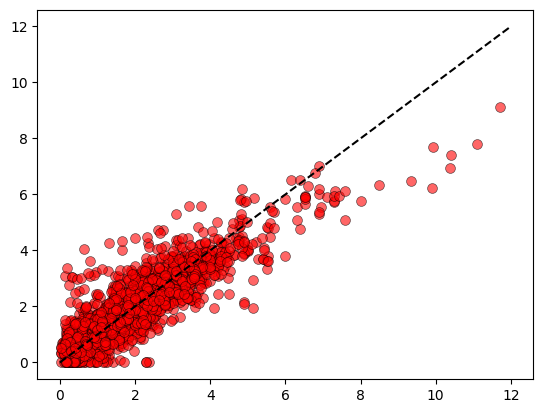

In [30]:
import matplotlib.pyplot as plt

# regresor for non metal
mask_non_metal = (y_test_raw > 0.001)
X_test_nm = X_test_scaled[mask_non_metal]
y_test_nm = y_test_raw[mask_non_metal]

# to tensor
X_test_nm = torch.FloatTensor(X_train_nm)
y_test_nm = torch.FloatTensor(y_train_nm).view(-1, 1)

model_reg.eval()
with torch.inference_mode():
  predictions = model_reg(X_test_nm)

plt.plot(np.arange(0, 12, 0.001), np.arange(0, 12, 0.001), ls="--", c="k")
plt.scatter(y_test_nm, predictions,c='red',      # Warna Biru Matplotlib standar
           alpha=0.6,        # Transparansi (0.0 - 1.0) agar tumpukan terlihat
           edgecolor='k',    # Garis pinggir titik (hitam) agar tajam
           linewidth=0.5,    # Ketebalan garis pinggir
           s=50,             # Ukuran titik
           label='Non-Metals');